In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import sys, os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from NNMFit.utilities import ScanHandler

# import plotting utils
sys.path.append( "/data/user/tvaneede/utils" )
from FlavourScansPlotting import get_contour_points, get_contour_points_angle

# import scanning points
from flavor_fracs import *
points = pd.read_pickle('/data/user/tvaneede/GlobalFit/custom_scan_flavor/default_custom_scan_points_flavor.pickle')
flavs = flavor_frac(np.asarray(points['astro_nue_ratio']),np.asarray(points['astro_nutau_ratio']))

# import plotting flavor triangle
sys.path.append( "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks" )
from plot_utils_triangle import *

# dict with all my dag scans
from scan_dict import scan_dir_dict

In [3]:
plotting_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/debug_minimizer/sensitivity"
os.system(f"mkdir -p {plotting_path}")

0

In [10]:
# load the data
drop_unsuccessful = False
scan_dict = {}
data = {}
for name, scan_dir in scan_dir_dict.items():
    print(name)
    print(scan_dir)
    scan_dict[name] = ScanHandler(scan_dir,dump=False,drop_unsuccessful=drop_unsuccessful)
    data[name] = {}
    if "3flavor" in name or "gf" in name:
        data[name]["ftau"],data[name]["fe"],data[name]["ts"],data[name]["ftau_grid"],data[name]["fe_grid"],data[name]["ts_grid"] = get_contour_points_angle(scan_dict,name)
    else:
        data[name]["ftau"],data[name]["fe"],data[name]["ts"],data[name]["ftau_grid"],data[name]["fe_grid"],data[name]["ts_grid"] = get_contour_points(scan_dict,name, N_grid=20)


spice_nosyst
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/first_try/asimov_SAY_HESEBestfit_NoSystematics_spice
removed stuff
hese_oldpid_nosyst
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/first_try/asimov_SAY_HESEBestfit_NoSystematics_ftp_FinalTopology
removed stuff
globalfit_double_SPL_LBFGSB
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/debug_minimizer/globalfit_double_SPL_LBFGSB
removed stuff
globalfit_double_SPL_minuit
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/debug_minimizer/globalfit_double_SPL_minuit
removed stuff
globalfit_double_SPL_minuit_philipp
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/debug_minimizer/globalfit_double_SPL_minuit_philipp
removed stuff
globalfit_double_no_hybrid_muon_SPL_LBFGSB
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/fl

Area ratio (globalfit_double_SPL_LBFGSB / globalfit_double_SPL_LBFGSB) at 68%: 1.0000
Area ratio (globalfit_double_SPL_minuit / globalfit_double_SPL_LBFGSB) at 68%: 0.9952
Area ratio (globalfit_double_SPL_minuit_philipp / globalfit_double_SPL_LBFGSB) at 68%: 0.9450


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

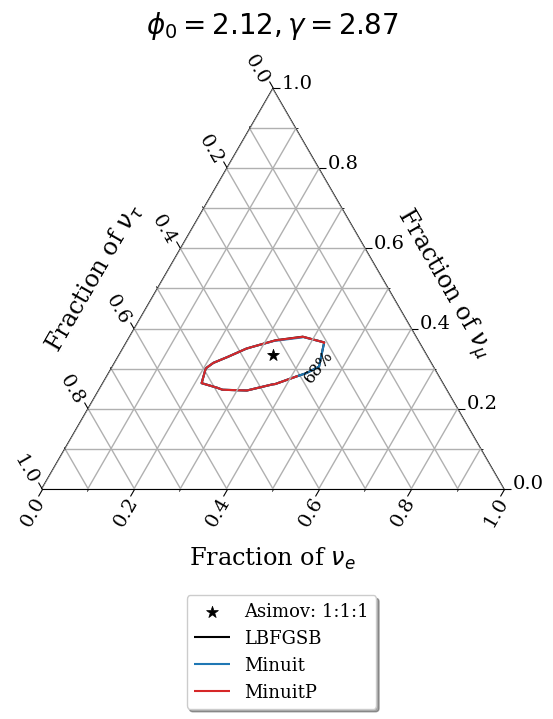

In [10]:
# spice_ftp_oldpid_bdtprod
names = [
"globalfit_double_SPL_LBFGSB",
"globalfit_double_SPL_minuit",
"globalfit_double_SPL_minuit_philipp",
]
labels = [
    "LBFGSB",
    "Minuit",
    "MinuitP",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 2.12,\gamma=2.87$",
                  savepath = f"{plotting_path}/globalfit_double_SPL.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_SPL_LBFGSB", levels=["68%"] )

Area ratio (globalfit_double_no_hybrid_muon_SPL_LBFGSB / globalfit_double_no_hybrid_muon_SPL_LBFGSB) at 68%: 1.0000
Area ratio (globalfit_double_no_hybrid_muon_SPL_minuit / globalfit_double_no_hybrid_muon_SPL_LBFGSB) at 68%: 0.9864
Area ratio (globalfit_double_no_hybrid_muon_SPL_minuit_philipp / globalfit_double_no_hybrid_muon_SPL_LBFGSB) at 68%: 0.7164


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

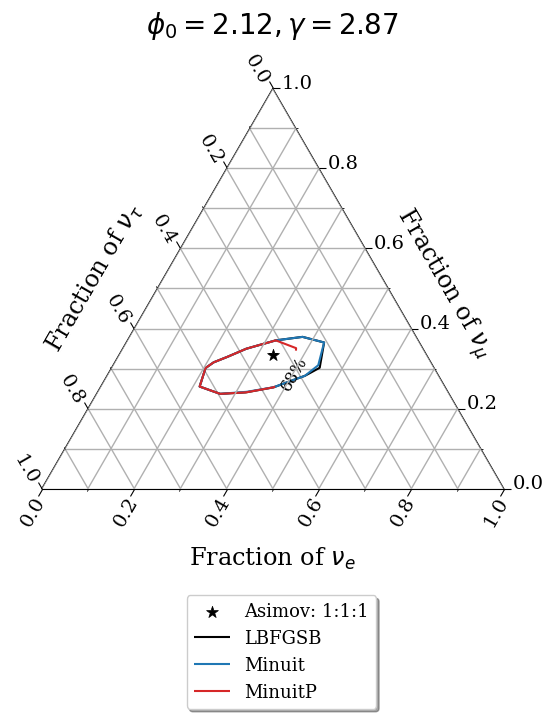

In [11]:
# spice_ftp_oldpid_bdtprod
names = [
"globalfit_double_no_hybrid_muon_SPL_LBFGSB",
"globalfit_double_no_hybrid_muon_SPL_minuit",
"globalfit_double_no_hybrid_muon_SPL_minuit_philipp",
]
labels = [
    "LBFGSB",
    "Minuit",
    "MinuitP",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 2.12,\gamma=2.87$",
                  savepath = f"{plotting_path}/globalfit_double_no_hybrid_muon.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_no_hybrid_muon_SPL_LBFGSB", levels=["68%"] )

Area ratio (globalfit_double_no_hybrid_muon_SPL_LBFGSB_Poisson / globalfit_double_no_hybrid_muon_SPL_LBFGSB_Poisson) at 68%: 1.0000
Area ratio (globalfit_double_no_hybrid_muon_SPL_minuit_Poisson / globalfit_double_no_hybrid_muon_SPL_LBFGSB_Poisson) at 68%: 0.3193
Area ratio (globalfit_double_no_hybrid_muon_SPL_minuit_philipp_Poisson / globalfit_double_no_hybrid_muon_SPL_LBFGSB_Poisson) at 68%: 0.9430


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

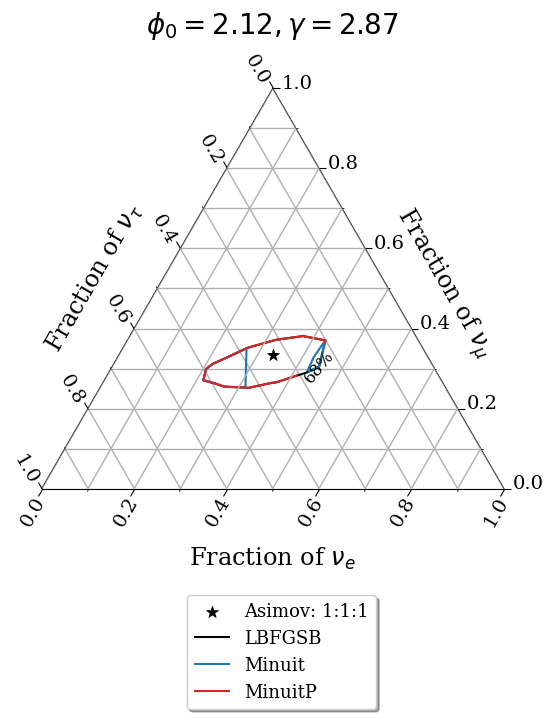

In [12]:
# spice_ftp_oldpid_bdtprod
names = [
"globalfit_double_no_hybrid_muon_SPL_LBFGSB_Poisson",
"globalfit_double_no_hybrid_muon_SPL_minuit_Poisson",
"globalfit_double_no_hybrid_muon_SPL_minuit_philipp_Poisson",
]
labels = [
    "LBFGSB",
    "Minuit",
    "MinuitP",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 2.12,\gamma=2.87$",
                  savepath = f"{plotting_path}/globalfit_double_no_hybrid_muon_SPL_Poisson.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_no_hybrid_muon_SPL_LBFGSB_Poisson", levels=["68%"] )

Area ratio (globalfit_double_SPL_LBFGSB / globalfit_double_SPL_LBFGSB) at 68%: 1.0000
Area ratio (globalfit_double_no_hybrid_muon_SPL_LBFGSB / globalfit_double_SPL_LBFGSB) at 68%: 1.0847
Area ratio (globalfit_double_no_hybrid_muon_SPL_LBFGSB_Poisson / globalfit_double_SPL_LBFGSB) at 68%: 0.9026


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

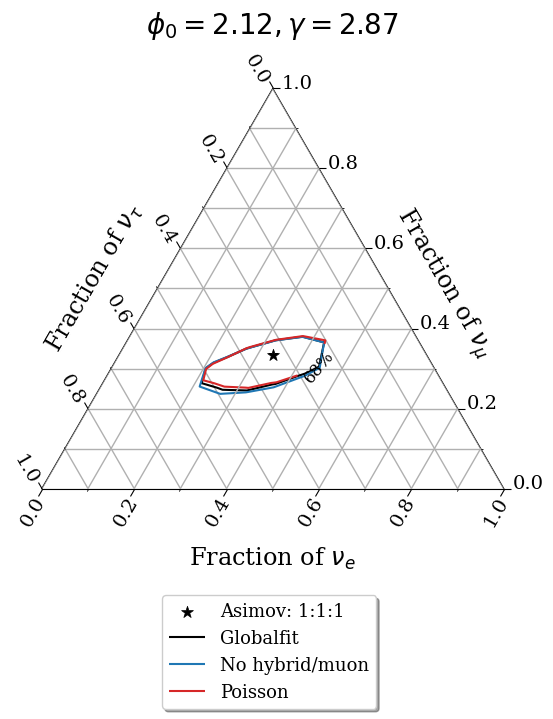

In [13]:
# spice_ftp_oldpid_bdtprod
names = [
"globalfit_double_SPL_LBFGSB",
"globalfit_double_no_hybrid_muon_SPL_LBFGSB",
"globalfit_double_no_hybrid_muon_SPL_LBFGSB_Poisson",
]
labels = [
    "Globalfit",
    "No hybrid/muon",
    "Poisson",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 2.12,\gamma=2.87$",
                  savepath = f"{plotting_path}/LBFGSB.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_SPL_LBFGSB", levels=["68%"] )

/data/user/tvaneede/utils/Ternary.py:74: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.xaxis.grid(*args, **kwargs)
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processi

Area ratio (globalfit_double_SPL_3flavor_LBFGSB / globalfit_double_SPL_3flavor_LBFGSB) at 68%: 1.0000
Area ratio (globalfit_double_no_hybrid_muon_SPL_3flavor_LBFGSB / globalfit_double_SPL_3flavor_LBFGSB) at 68%: 1.1272
Area ratio (globalfit_double_no_hybrid_muon_SPL_3flavor_LBFGSB_Poisson / globalfit_double_SPL_3flavor_LBFGSB) at 68%: 0.8727


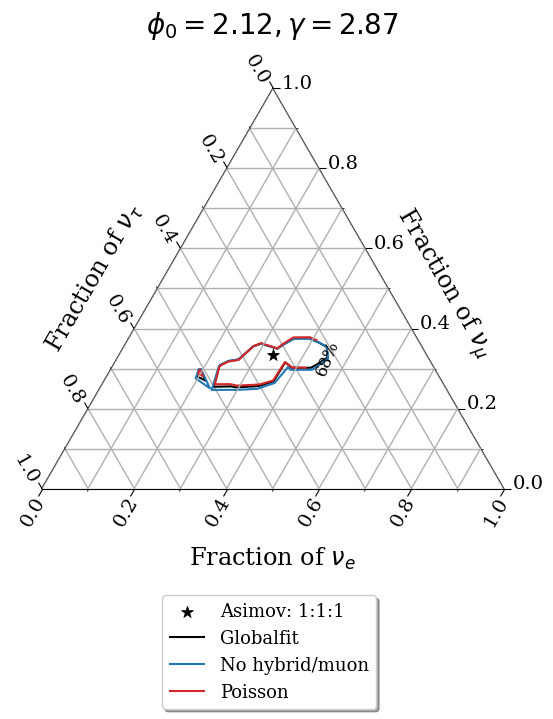

In [18]:
# spice_ftp_oldpid_bdtprod
names = [
"globalfit_double_SPL_3flavor_LBFGSB",
"globalfit_double_no_hybrid_muon_SPL_3flavor_LBFGSB",
"globalfit_double_no_hybrid_muon_SPL_3flavor_LBFGSB_Poisson",
]
labels = [
    "Globalfit",
    "No hybrid/muon",
    "Poisson",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 2.12,\gamma=2.87$",
                  savepath = f"{plotting_path}/SPL_3flavor.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_SPL_3flavor_LBFGSB", levels=["68%"] )

/data/user/tvaneede/utils/Ternary.py:74: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.xaxis.grid(*args, **kwargs)


Area ratio (globalfit_double_no_hybrid_muon_BPL_LBFGSB / globalfit_double_no_hybrid_muon_BPL_LBFGSB) at 68%: 1.0000
Area ratio (globalfit_double_no_hybrid_muon_BPL_3flavor_LBFGSB / globalfit_double_no_hybrid_muon_BPL_LBFGSB) at 68%: 0.6062
Area ratio (globalfit_double_BPL_LBFGSB / globalfit_double_no_hybrid_muon_BPL_LBFGSB) at 68%: 0.7038


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

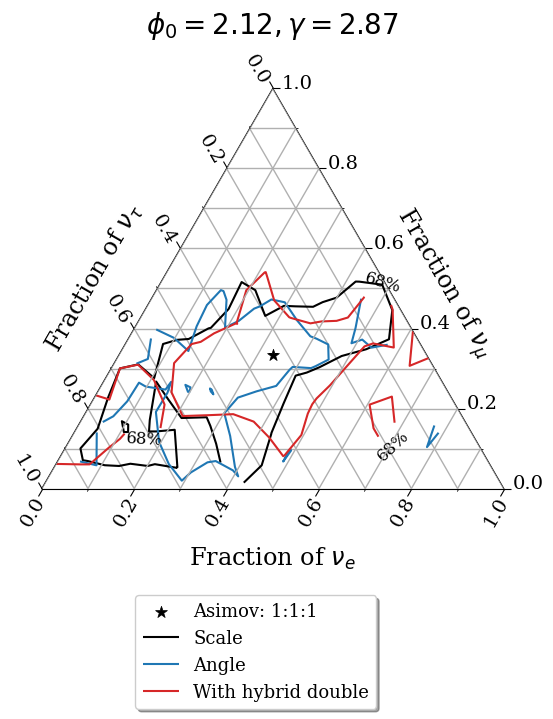

In [5]:
# spice_ftp_oldpid_bdtprod
names = [
"globalfit_double_no_hybrid_muon_BPL_LBFGSB",
"globalfit_double_no_hybrid_muon_BPL_3flavor_LBFGSB",
"globalfit_double_BPL_LBFGSB",
]
labels = [
    "Scale",
    "Angle",
    "With hybrid double",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 2.12,\gamma=2.87$",
                  savepath = f"{plotting_path}/BPL.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_no_hybrid_muon_BPL_LBFGSB", levels=["68%"] )

Area ratio (globalfit_double_SPL_LBFGSB_Poisson / globalfit_double_SPL_LBFGSB_Poisson) at 68%: 1.0000
Area ratio (globalfit_double_nohese_SPL_LBFGSB_Poisson / globalfit_double_SPL_LBFGSB_Poisson) at 68%: 2.1608
Area ratio (globalfit_double_nohese_BPL_LBFGSB_Poisson / globalfit_double_SPL_LBFGSB_Poisson) at 68%: 1.3963


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

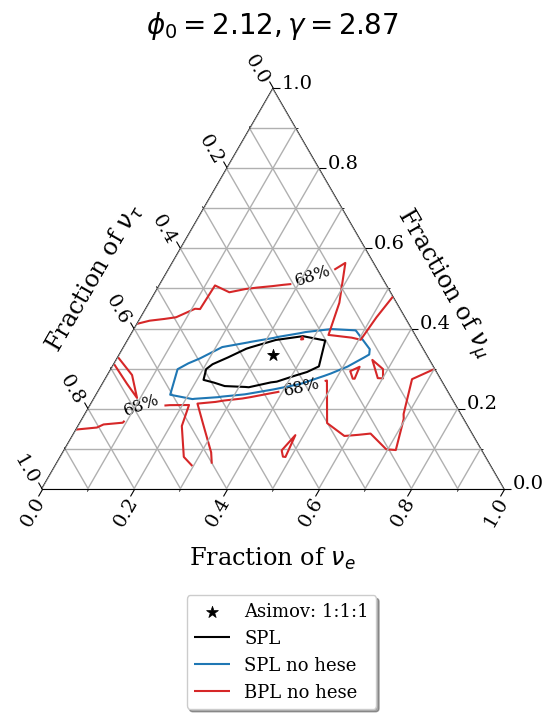

In [6]:
# spice_ftp_oldpid_bdtprod
names = [
"globalfit_double_SPL_LBFGSB_Poisson",
"globalfit_double_nohese_SPL_LBFGSB_Poisson",
"globalfit_double_nohese_BPL_LBFGSB_Poisson",
]
labels = [
    "SPL",
    "SPL no hese",
    "BPL no hese",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 2.12,\gamma=2.87$",
                  savepath = f"{plotting_path}/nohese.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_SPL_LBFGSB_Poisson", levels=["68%"] )

Area ratio (globalfit_double_hese_SPL / globalfit_double_hese_SPL) at 68%: 1.0000
Area ratio (globalfit_double_hese_BPL / globalfit_double_hese_SPL) at 68%: 1.8810


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

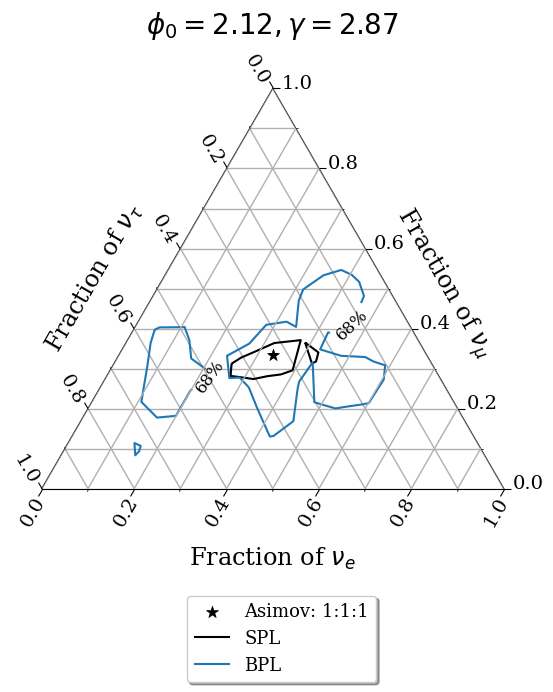

In [7]:
# spice_ftp_oldpid_bdtprod
names = [
"globalfit_double_hese_SPL",
"globalfit_double_hese_BPL",
]
labels = [
    "SPL",
    "BPL",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 2.12,\gamma=2.87$",
                  savepath = f"{plotting_path}/globalfit_double_hese.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_hese_SPL", levels=["68%"] )

/data/user/tvaneede/utils/Ternary.py:74: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.xaxis.grid(*args, **kwargs)


Area ratio (globalfit_double_no_hybrid_muon_BPL_range_philipp_LBFGSB / globalfit_double_no_hybrid_muon_BPL_range_philipp_LBFGSB) at 68%: 1.0000
Area ratio (globalfit_double_no_hybrid_muon_BPL_range_philipp_strict_LBFGSB / globalfit_double_no_hybrid_muon_BPL_range_philipp_LBFGSB) at 68%: 0.1151


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

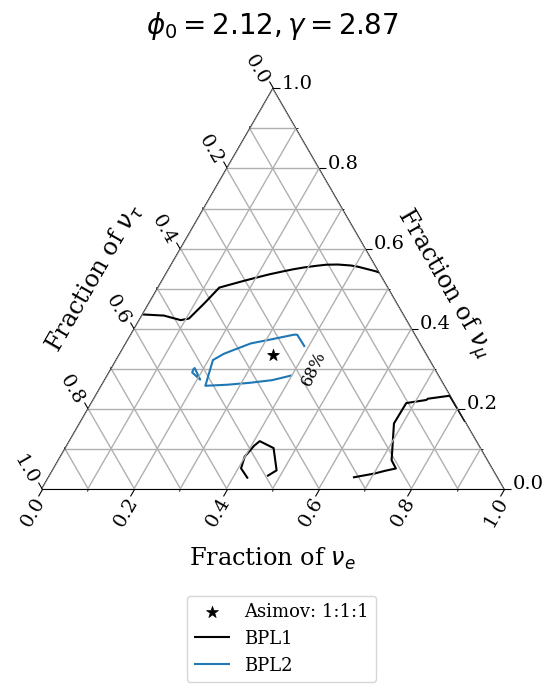

In [5]:
# spice_ftp_oldpid_bdtprod
names = [
"globalfit_double_no_hybrid_muon_BPL_range_philipp_LBFGSB",
"globalfit_double_no_hybrid_muon_BPL_range_philipp_strict_LBFGSB",
]
labels = [
    "BPL1",
    "BPL2",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 2.12,\gamma=2.87$",
                  savepath = f"{plotting_path}/BPL_range.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_no_hybrid_muon_BPL_range_philipp_LBFGSB", levels=["68%"] )

Area ratio (globalfit_double_no_hybrid_muon_BPL_range_philipp_strict_LBFGSB / globalfit_double_no_hybrid_muon_BPL_range_philipp_strict_LBFGSB) at 68%: 1.0000
Area ratio (globalfit_double_no_hybrid_muon_BPL_range_philipp_strict_LBFGSB_fine / globalfit_double_no_hybrid_muon_BPL_range_philipp_strict_LBFGSB) at 68%: 1.3213
Area ratio (globalfit_double_no_hybrid_muon_BPL_range_philipp_strict_LBFGSB_fine_center / globalfit_double_no_hybrid_muon_BPL_range_philipp_strict_LBFGSB) at 68%: 1.5763


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

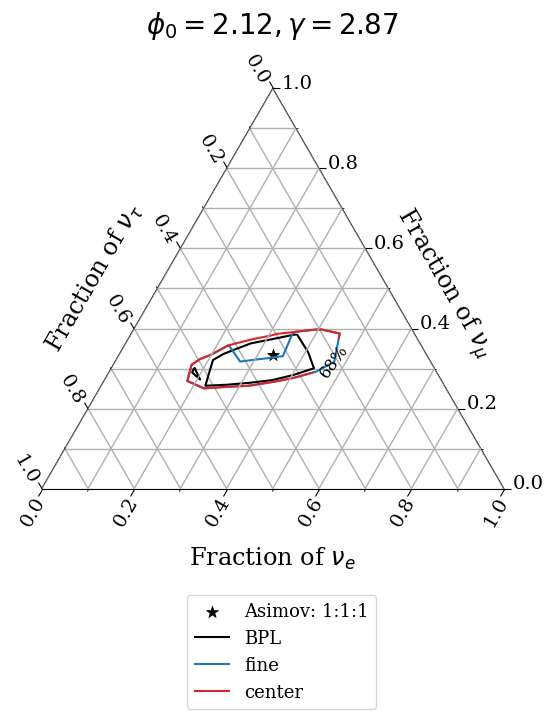

In [6]:
# spice_ftp_oldpid_bdtprod
names = [
"globalfit_double_no_hybrid_muon_BPL_range_philipp_strict_LBFGSB",
"globalfit_double_no_hybrid_muon_BPL_range_philipp_strict_LBFGSB_fine",
"globalfit_double_no_hybrid_muon_BPL_range_philipp_strict_LBFGSB_fine_center",
]
labels = [
    "BPL",
    "fine",
    "center",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 2.12,\gamma=2.87$",
                  savepath = f"{plotting_path}/BPL_fine.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_no_hybrid_muon_BPL_range_philipp_strict_LBFGSB", levels=["68%"] )

Area ratio (globalfit_double_hese_BPL_range_philipp_strict / globalfit_double_hese_BPL_range_philipp_strict) at 68%: 1.0000
Area ratio (globalfit_double_hese_BPL_range_philipp_strict_fine_center / globalfit_double_hese_BPL_range_philipp_strict) at 68%: 1.2867


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

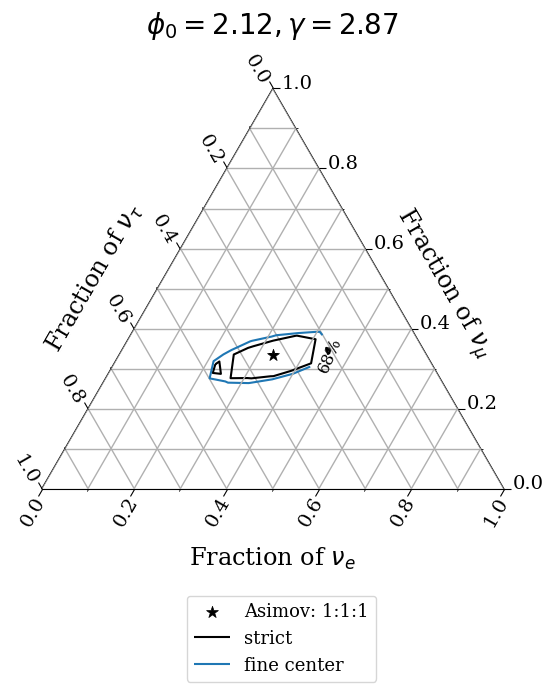

In [7]:
# spice_ftp_oldpid_bdtprod
names = [
"globalfit_double_hese_BPL_range_philipp_strict",
"globalfit_double_hese_BPL_range_philipp_strict_fine_center",
]
labels = [
    "strict",
    "fine center",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 2.12,\gamma=2.87$",
                  savepath = f"{plotting_path}/gfh_BPL_strict_fine.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_hese_BPL_range_philipp_strict", levels=["68%"] )

Area ratio (globalfit_double_BPL_range_philipp_strict_LBFGSB_fine_center / globalfit_double_BPL_range_philipp_strict_LBFGSB_fine_center) at 68%: 1.0000
Area ratio (globalfit_double_nohese_BPL_range_philipp_strict_LBFGSB_fine_center / globalfit_double_BPL_range_philipp_strict_LBFGSB_fine_center) at 68%: 1.6827
Area ratio (globalfit_double_hese_BPL_range_philipp_strict_fine_center / globalfit_double_BPL_range_philipp_strict_LBFGSB_fine_center) at 68%: 0.6767


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

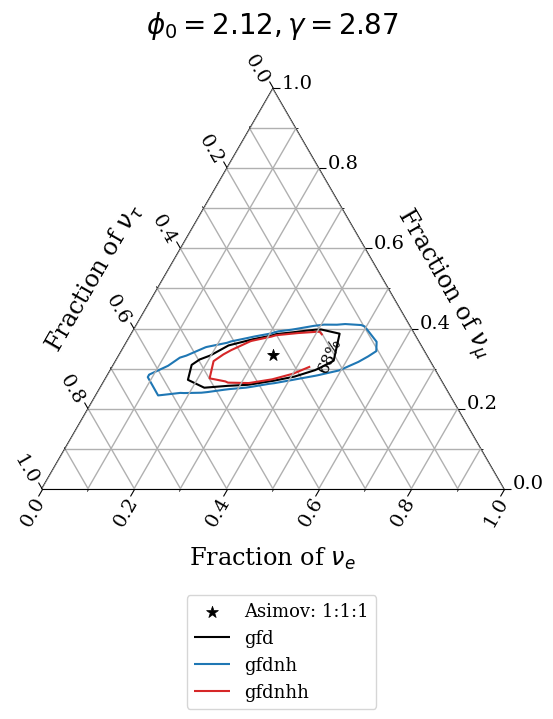

In [12]:
# spice_ftp_oldpid_bdtprod
names = [
"globalfit_double_BPL_range_philipp_strict_LBFGSB_fine_center",
"globalfit_double_nohese_BPL_range_philipp_strict_LBFGSB_fine_center",
"globalfit_double_hese_BPL_range_philipp_strict_fine_center",
]
labels = [
    "gfd",
    "gfdnh",
    "gfdnhh",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 2.12,\gamma=2.87$",
                  savepath = f"{plotting_path}/gfd_gfdnh_gfdnhh.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_BPL_range_philipp_strict_LBFGSB_fine_center", levels=["68%"] )

/data/user/tvaneede/utils/Ternary.py:74: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.xaxis.grid(*args, **kwargs)


Area ratio (spice_nosyst / spice_nosyst) at 68%: 1.0000
Area ratio (hese_allfeat_bdtprod_combinedBase_Muon / spice_nosyst) at 68%: 0.6159
Area ratio (globalfit_double_SPL_LBFGSB_Poisson / spice_nosyst) at 68%: 0.1642
Area ratio (globalfit_double_nohese_SPL_LBFGSB_Poisson / spice_nosyst) at 68%: 0.3479
Area ratio (globalfit_double_hese_SPL / spice_nosyst) at 68%: 0.0807


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

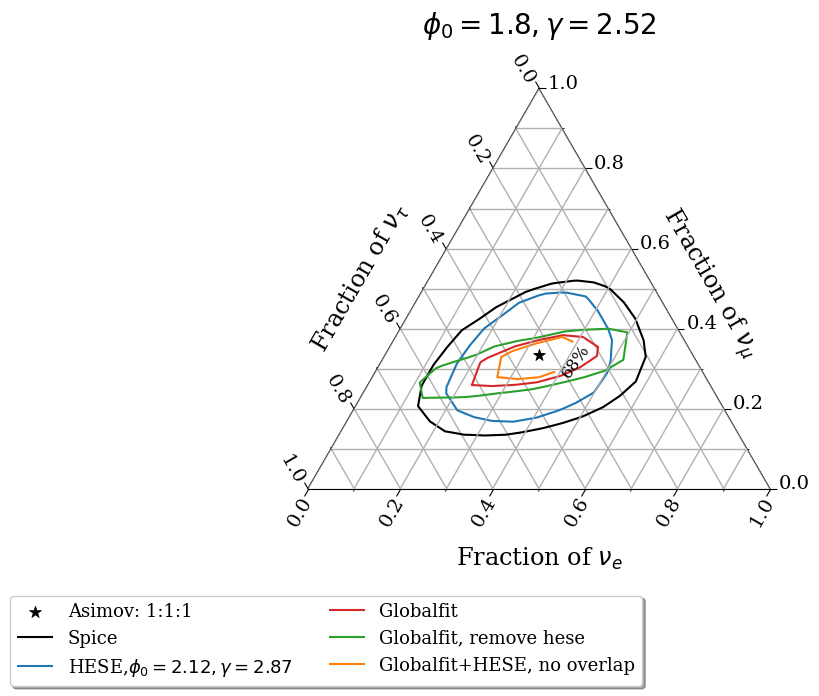

In [19]:
# spice_ftp_oldpid_bdtprod
names = [
"spice_nosyst",
"hese_allfeat_bdtprod_combinedBase_Muon",
"globalfit_double_SPL_LBFGSB_Poisson",
"globalfit_double_nohese_SPL_LBFGSB_Poisson",
"globalfit_double_hese_SPL",
]
labels = [
    "Spice",
    r"HESE,$\phi_0 = 2.12,\gamma=2.87$",
    "Globalfit",
    "Globalfit, remove hese",
    "Globalfit+HESE, no overlap",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 1.8,\gamma=2.52$",
                  savepath = f"{plotting_path}/meeting_update.png")

for name in names: compare_area( C, alt_key=name, base_key="spice_nosyst", levels=["68%"] )